## 1. Data exploration and preparation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import nltk
import spacy
import networkx as nx
from wordcloud import WordCloud
from nltk.corpus import stopwords
from bertopic import BERTopic
from sklearn.linear_model              import LogisticRegression
from sklearn.model_selection           import cross_val_score, train_test_split
from sklearn.metrics                   import confusion_matrix, classification_report, ConfusionMatrixDisplay, accuracy_score
from sklearn.feature_extraction.text   import CountVectorizer
from sklearn.preprocessing import LabelEncoder


### 1.1. Data Preparation: dropping small Subreddits

In [2]:
df = pd.read_csv('data/reddit_posts.csv')

In [3]:
df.Subreddit.value_counts()

Subreddit
alltheleft             796
conservatives          782
republicans            773
Capitalism             771
socialism              768
progressive            765
SocialDemocracy        762
Libertarian            758
feminisms              740
DemocraticSocialism    730
Liberal                727
democrats              703
anarchocapitalism      489
Communist              435
Name: count, dtype: int64

### 1.2 viewing scores and number of Comments

In [4]:
def plot_subreddit(column, x_max=400, y_max=500, bin_size=10):
    '''plots the distribution of a column in the subreddits'''
    axes = df[column].hist(
        by=df.Subreddit,
        bins=np.arange(0, x_max+1, bin_size),
        figsize=(12, 8),
        color='#08415C',  
    )
    plt.suptitle(f"Distributions of {column} in Subreddits.", fontsize=20, fontweight='bold', y=0.98)

    for ax in np.ravel(axes):
        # ax.set_ylim(0, y_max)
        ax.set_yscale('log')
        ax.set_xscale('log')


        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        if len(ax.patches) > 0:
            ax.patches[0].set_facecolor('#FF2C3D')
    plt.tight_layout()
    plt.show()

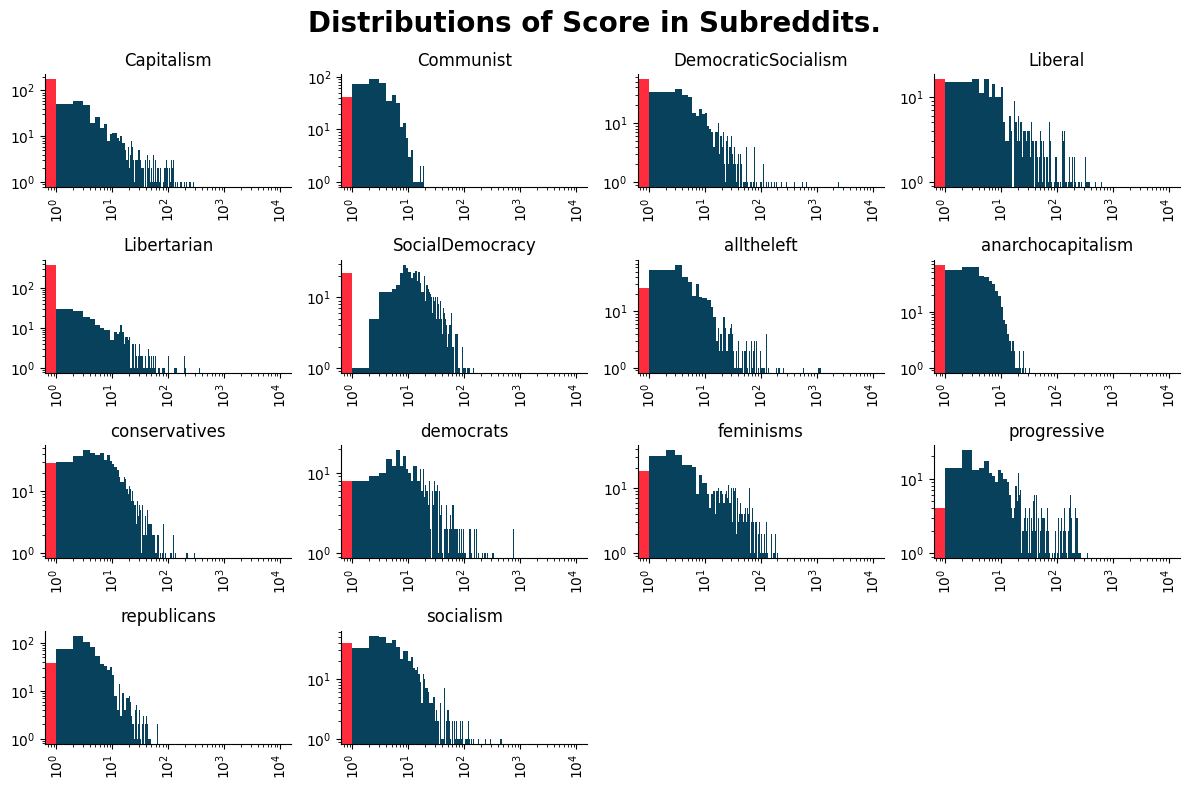

In [5]:
plot_subreddit("Score", 10000, 1000, 1)


We can see how popular posts are in different subreddits. Some have a lot of controversial posts with values close to 0 like *libertarian*. While others have a more uniform distribution like *feminisms*.

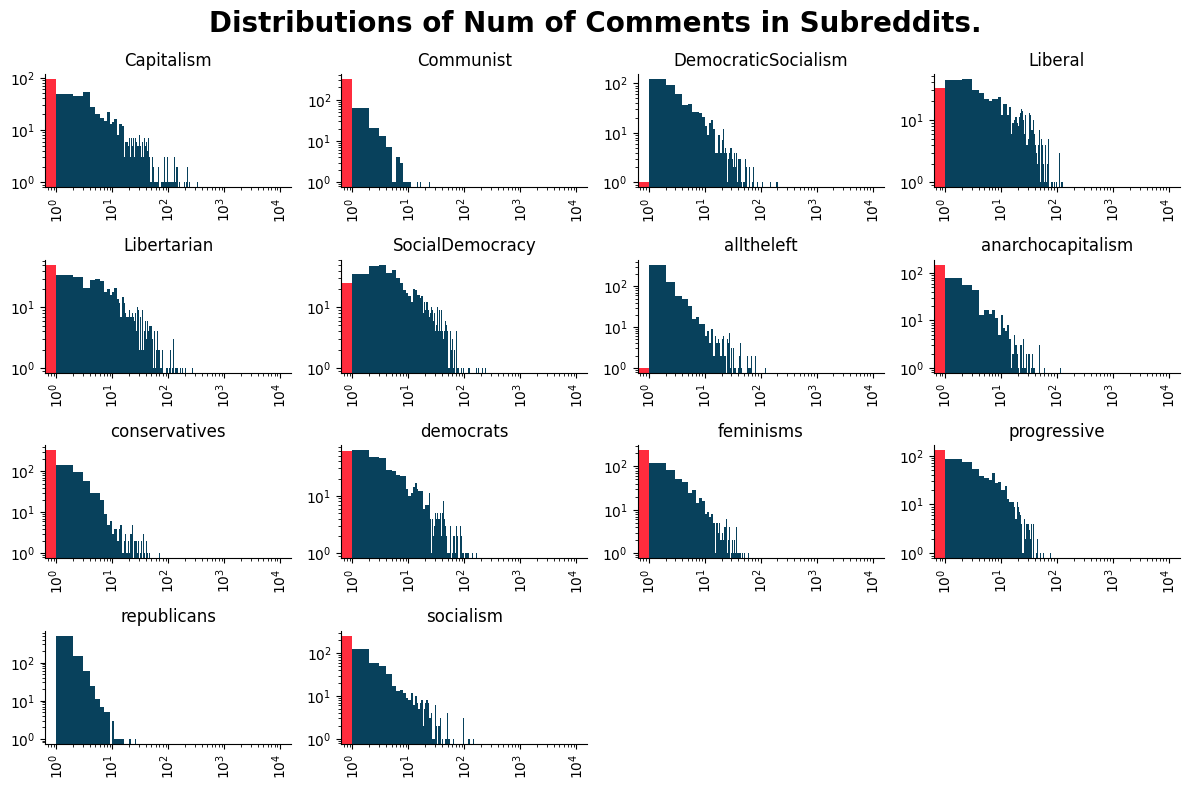

In [6]:
plot_subreddit('Num of Comments', 10000, 1000, 1)


Number of Comments really vary depending on the Subreddit. This can highlight different practices in subreddits. For instance *republicans* and *alltheleft* don't have posts with 0 comments while *conservativees* and *feminism* have a lot of them. This can be the difference between subbredits centered around for debates and discussions and subreddits made for posting.

## 2. Data preprocessing

### 2.1 removing urls, and standardising time

In [7]:
df['Date Created'] = pd.to_datetime(df['Date Created'], unit='s')
df = df.rename(columns={"Title": "title", "Text": "selftext"})
combined = df['title'].fillna('') + ' ' + df['selftext'].fillna('')
url_pattern = r'https?://\S+'
has_url = combined.str.contains(url_pattern)
print(f"{has_url.sum()} posts contain URLs out of {len(df)} total")

df['title']    = df['title'].str.replace(url_pattern, '', regex=True)
df['selftext'] = df['selftext'].str.replace(url_pattern, '', regex=True)

503 posts contain URLs out of 9999 total


### 2.2 Removing short tokens, lemmatizing and removing stop words
To download the model, use 
```py
python -m spacy download en_core_web_sm
```

In [8]:
spacy_tokenize = spacy.load(
    "en_core_web_sm",
    disable=["parser","ner","textcat"]
)

def clean_str(text: str) -> str:
    '''filters out non-alphabetic characters, short tokens and stop words, and lemmatizes'''
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    lemmas = [
        token.lemma_
        for token in spacy_tokenize(text)
        if token.is_alpha                
           and not token.is_stop        
           and len(token.lemma_) >= 3   
    ]
    return " ".join(lemmas)

df["title"]    = df["title"].apply(clean_str)
df["selftext"] = df["selftext"].apply(clean_str)

## 3. Topic Modelling

In [9]:
list(df.columns)


['title',
 'Political Lean',
 'Score',
 'Subreddit',
 'Num of Comments',
 'selftext',
 'Date Created']

In [10]:
list(df.Subreddit.unique())

['socialism',
 'democrats',
 'DemocraticSocialism',
 'progressive',
 'alltheleft',
 'Liberal',
 'SocialDemocracy',
 'Communist',
 'feminisms',
 'Libertarian',
 'conservatives',
 'Capitalism',
 'republicans',
 'anarchocapitalism']

### 3.1 prepare the docs and labels for prediction

In [11]:
docs = (df['title'].fillna('') + ' ' + df['selftext'].fillna('')).tolist()

# Encode Subreddit as integers
le = LabelEncoder()
y = le.fit_transform(df['Subreddit'])
subreddit_names = le.classes_


### 3.2 Fit BERTopic and Bet Topic Probabilities


In [12]:
topic_model = BERTopic(calculate_probabilities=True, verbose=True)
topics, probs = topic_model.fit_transform(docs)


2025-06-08 17:27:20,929 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/313 [00:00<?, ?it/s]

2025-06-08 17:28:00,104 - BERTopic - Embedding - Completed ✓
2025-06-08 17:28:00,104 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-06-08 17:28:16,140 - BERTopic - Dimensionality - Completed ✓
2025-06-08 17:28:16,141 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-06-08 17:28:21,888 - BERTopic - Cluster - Completed ✓
2025-06-08 17:28:21,892 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-06-08 17:28:22,127 - BERTopic - Representation - Completed ✓


## 4. Predicting Subreddit based on Topic Distribution

### 4.1 Predict Subreddit based on Topic distribution


In [13]:
plt.rcdefaults()

In [14]:
X = np.array(probs)  # shape: (n_docs, n_topics)


# 3. Evaluate with 5-Fold Cross-Validation (Macro F1)
clf = LogisticRegression(max_iter=1000, multi_class='multinomial', solver='lbfgs', class_weight='balanced')
f1_scores = cross_val_score(clf, X, y, cv=5, scoring="f1_macro")
print(f"5-fold CV Macro F1: {f1_scores.mean():.3f} ± {f1_scores.std():.3f}")

# Train/test split for confusion matrix
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred, target_names=subreddit_names))

conf_mat = confusion_matrix(y_test, y_pred)


5-fold CV Macro F1: 0.289 ± 0.025
                     precision    recall  f1-score   support

         Capitalism       0.35      0.66      0.46       154
          Communist       0.47      0.48      0.48        87
DemocraticSocialism       0.25      0.11      0.15       146
            Liberal       0.31      0.37      0.34       145
        Libertarian       0.41      0.17      0.24       152
    SocialDemocracy       0.31      0.31      0.31       152
         alltheleft       0.29      0.21      0.24       159
  anarchocapitalism       0.18      0.35      0.23        98
      conservatives       0.27      0.28      0.27       156
          democrats       0.36      0.28      0.32       141
          feminisms       0.72      0.76      0.74       148
        progressive       0.19      0.30      0.23       153
        republicans       0.44      0.21      0.29       155
          socialism       0.25      0.19      0.21       154

           accuracy                           0.3

In [25]:
democrats = [
    "alltheleft", "socialism", "progressive", "SocialDemocracy",
    "feminisms", "DemocraticSocialism", "Liberal", "democrats", "Communist"
]

conservatives = ["republicans", "conservatives", "anarchocapitalism", "Libertarian", "Capitalism"]

labels_with_gap = conservatives + [""] + democrats

label_to_index = {name: i for i, name in enumerate(subreddit_names)}
indices = [label_to_index[name] if name != "" else -1 for name in labels_with_gap]
N = len(conservatives) + len(democrats)
conf_mat_with_gap = np.zeros((N+1, N+1), dtype=conf_mat.dtype)
for new_i, orig_i in enumerate(indices):
    for new_j, orig_j in enumerate(indices):
        if orig_i == -1 or orig_j == -1:
            conf_mat_with_gap[new_i, new_j] = 0  # gap row/column
        else:
            conf_mat_with_gap[new_i, new_j] = conf_mat[orig_i, orig_j]

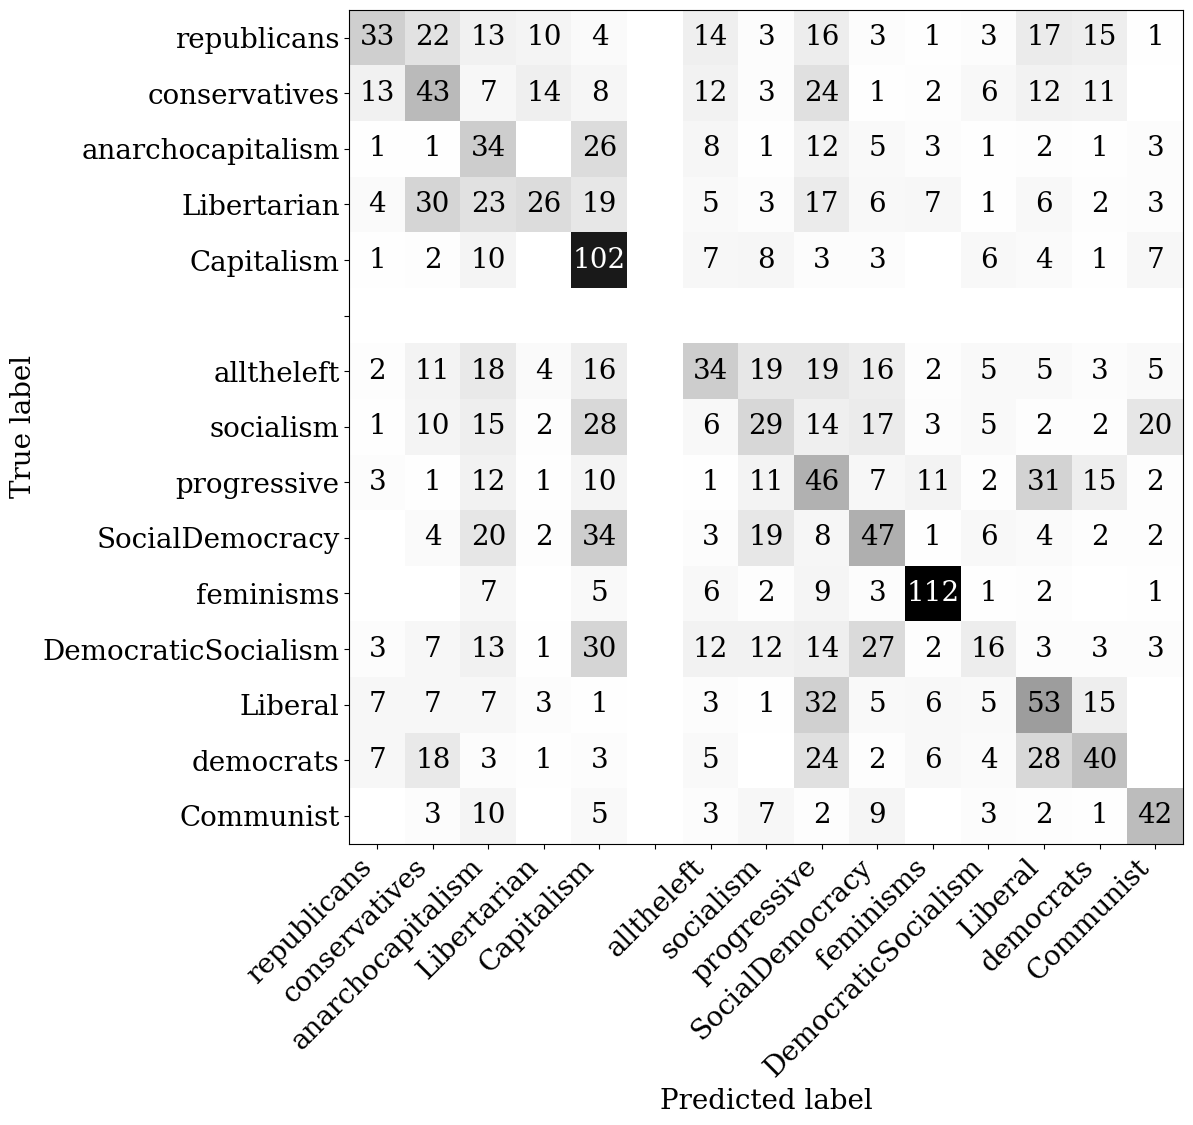

In [26]:
plt.rcParams["font.family"] = "serif"
fig, ax = plt.subplots(figsize=(12, 12))

disp = ConfusionMatrixDisplay(
    confusion_matrix=conf_mat_with_gap,
    display_labels=labels_with_gap
)
disp.plot(
    ax=ax, 
    cmap="Greys", 
    colorbar=False,
    )
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

for txt in ax.texts:
    txt.set_visible(False)
max_val = conf_mat_with_gap.max()
threshold = max_val * 0.5
for (i, j), value in np.ndenumerate(conf_mat_with_gap):
    if value == 0:
        color = "white"
    elif value <= threshold:
        color = "black"
    else:
        color = "white"
    ax.text(j, i, str(value), ha="center", va="center", color=color, fontsize=20)

ax.grid(False)
ax.set_facecolor("white")
fig.patch.set_facecolor("white")

ax.set_xlabel(ax.get_xlabel(), fontsize=20)
ax.set_ylabel(ax.get_ylabel(), fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=20)
# plt.title("Logistic Regression — Subreddit Confusion Matrix")
plt.tight_layout()
plt.show()


We can see that subreddits are more or less identifiable from the topics, found in the corpus. In particular, *feminisms* and *capitalism* are dealing with different topics than the rest of the dataset and is therefore more identifiable, with an f1-score of 0.54. The rest of the dataset is quite uniform in topics dealt with. We can see relevant clusters of Subreddits being formed.

### 4.2 Visualize Confusion Matrix as a graph

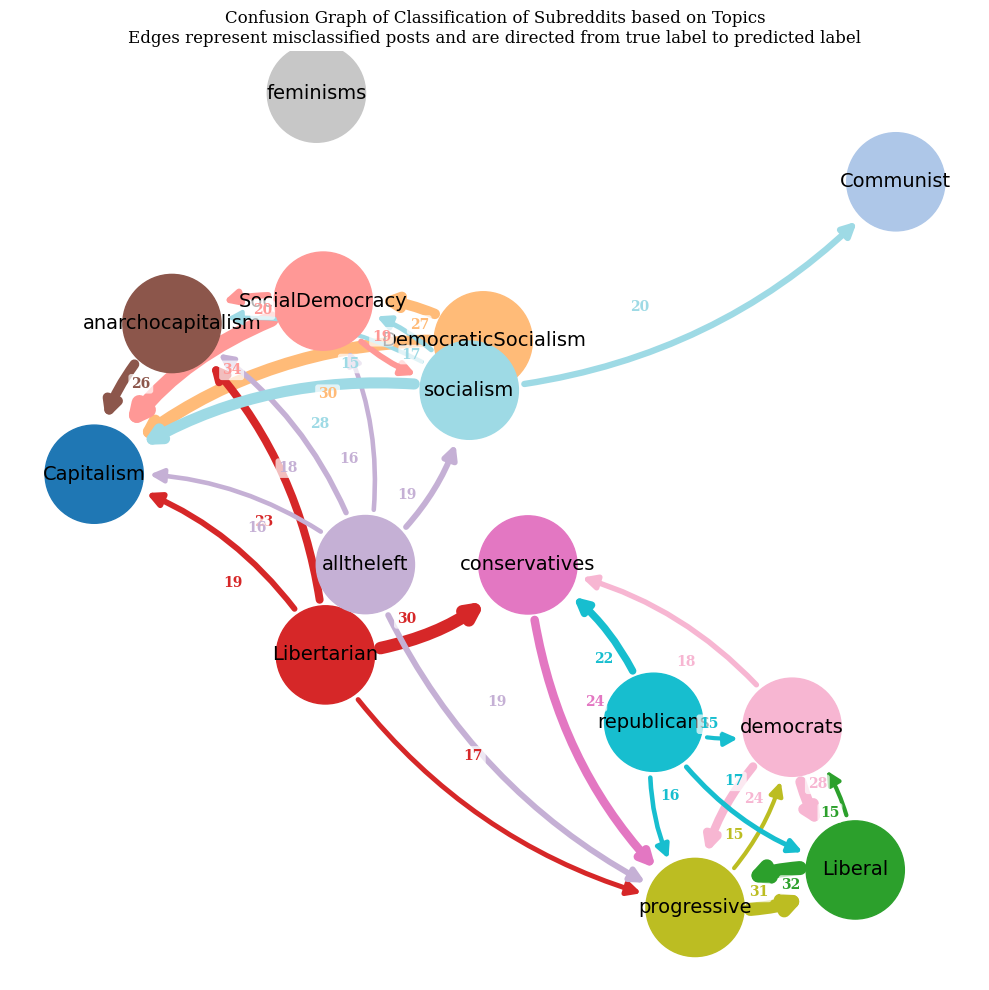

In [27]:
MIN_EDGE_WEIGHT = 14


n_classes = conf_mat.shape[0]
G = nx.DiGraph()
for i in range(n_classes):
    G.add_node(subreddit_names[i])
for i in range(n_classes):
    for j in range(n_classes):
        if conf_mat[i, j] > MIN_EDGE_WEIGHT:
            G.add_edge(subreddit_names[i], subreddit_names[j], weight=conf_mat[i, j])
G.remove_edges_from(nx.selfloop_edges(G))



pos = nx.spring_layout(G,k=5,iterations=100, scale=2, center=[0, 0], seed=78)
cmap = plt.get_cmap('tab20', n_classes)
node_colors = [cmap(i) for i in range(n_classes)]
node_color_dict = dict(zip(subreddit_names, node_colors))
plt.figure(figsize=(10, 10))
node_size = 5000
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_size)
node_radius = np.sqrt(node_size/np.pi)
for i, node in enumerate(subreddit_names):
    outgoing_edges = [(node, tgt) for tgt in subreddit_names if G.has_edge(node, tgt)]
    weights = [G[node][tgt]['weight'] for tgt in subreddit_names if G.has_edge(node, tgt)]
    widths = [1 + (w*w/np.max(conf_mat)) for w in weights]
    nx.draw_networkx_edges(
        G, pos,
        edgelist=outgoing_edges,
        edge_color=[node_colors[i]]*len(outgoing_edges),
        width=widths,
        arrowsize=20,
        alpha=1,
        connectionstyle='arc3,rad=0.2',
        min_source_margin=node_radius,
        min_target_margin=node_radius
    )
nx.draw_networkx_labels(G, pos, font_size=14, font_color='black')
ax = plt.gca()
edge_labels = {(u, v): d['weight'] for u, v, d in G.edges(data=True)}
for (u, v), label in edge_labels.items():
    x1, y1 = pos[u]
    x2, y2 = pos[v]
    label_x = 0.6 * x1 + 0.4 * x2
    label_y = 0.6 * y1 + 0.4 * y2
    ax.text(label_x, label_y, str(label), color=node_color_dict[u],
            fontsize=10, fontweight='bold', ha='center', va='center',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, boxstyle='round,pad=0.2'))
plt.title("Confusion Graph of Classification of Subreddits based on Topics\n"
          "Edges represent misclassified posts and are directed from true label to predicted label")
plt.axis('off')
plt.tight_layout()
plt.show()


Another way to visualize this confusion in our predictor is by using a graph and assigning edges to the most common misclassifications. The directed edge represents the misclassified posts that move from their true subreddit towards the predicted subreddit. Then we can visualize the relationship between subreddits. Note that we removed selfloops and edges with weight < 15 for readability. 


We can see that *communist* and *feminisms* are quite separated, 

## 5. Information Content of Topics in Subreddits
Even though the results are not very satisfying, we can still get a look at different topics. In particular it is interesting to evaluate how informative a given topic is at determining the subreddit. For that we can compute the Negative entropy of the probability distribution of a given topic among the subreddits.

### 5.1 Compute Topic Distribution Across Subreddits

In [28]:
probs_df = pd.DataFrame(probs, columns=range(probs.shape[1]))
probs_df['Subreddit'] = df['Subreddit'].values
topic_by_sub = probs_df.groupby('Subreddit').mean().T  # shape: n_topics x n_subreddits
topic_by_sub_norm = topic_by_sub.div(topic_by_sub.sum(axis=1), axis=0)


### 5.2 Compute Information Content (Negative Entropy)

In [29]:
def entropy(p):
    p = p[p > 0]  # avoid log(0)
    return -np.sum(p * np.log2(p))

n_subreddits = topic_by_sub_norm.shape[1]
max_entropy = np.log2(n_subreddits)

info_content = topic_by_sub_norm.apply(entropy, axis=1)
info_content = max_entropy - info_content  # Higher = more informative


### 5.3 Distribution of Topic Information

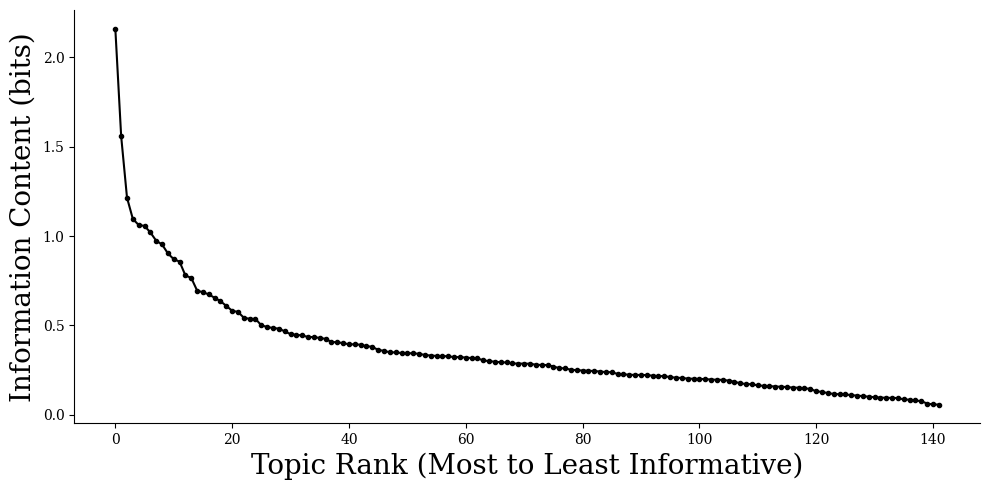

In [33]:
sorted_info = info_content.sort_values(ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 5))
plt.plot(sorted_info.values, marker='.', color='black')
# plt.title("Distribution of Topic Information Content (Negative Entropy)")
plt.xlabel("Topic Rank (Most to Least Informative)", fontsize=20)
plt.ylabel("Information Content (bits)", fontsize=20)
plt.grid(True, color='gray', linestyle='--', linewidth=0.5)
plt.grid(False)
ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.tight_layout()
plt.show()

We can see a clear heavy tail distribution: a few topics are very heplful to differentiate between the subreddit, while most topics don't contain a lot of information to determinate which subreddit a given post is taken from.

### 5.4 Taking a look at the most Informative Topics

In [34]:
threshold = 0.75
filtered_topics = info_content[info_content > threshold].sort_values(ascending=False).index.tolist()
print(f"Topics with information content > {threshold} (sorted):", filtered_topics)




Topics with information content > 0.75 (sorted): [109, 5, 29, 77, 12, 17, 92, 134, 11, 0, 4, 21, 120, 112]


In [ ]:
def topics_wordcloud(topics, latex_table=False):
    n_words = 15
    for tid in topics:
        words_scores = topic_model.get_topic(tid)[:n_words]  
        topic_words = []
        for word, score in words_scores:
            topic_words.extend([word] * int(score * 1000))
        
        top15 = words_scores[:15]
        df_15 = pd.DataFrame(top15, columns=["Word", "TF-IDF Score"])

        topic_dist = topic_by_sub_norm.loc[tid]
        df_topic = topic_dist.reset_index()
        df_topic.columns = ["Subreddit", "Probability"]
        df_topic = df_topic.sort_values(by="Probability", ascending=False)


        if topic_words:
            wordcloud = WordCloud(width=600, height=300, 
                                background_color="white",
                                colormap="tab20",
                                collocations=False).generate(" ".join(topic_words))
            
            plt.figure(figsize=(8, 4))
            plt.imshow(wordcloud, interpolation="bilinear")
            plt.axis("off")
            plt.title(f"Topic {tid} (IC: {info_content[tid]:.2f}) - Word Cloud")
            plt.tight_layout()
            
            if latex_table:
                n_rows = max(len(df_topic), len(df_15))
                subreddits = list(df_topic["Subreddit"]) + [""] * (n_rows - len(df_topic))
                probs = list(df_topic["Probability"]) + [""] * (n_rows - len(df_topic))
                words = list(df_15["Word"]) + [""] * (n_rows - len(df_15))
                tfidfs = list(df_15["TF-IDF Score"]) + [""] * (n_rows - len(df_15))
                df_combined = pd.DataFrame({
                    "Subreddit": subreddits,
                    "Probability": probs,
                    "Word": words,
                    "TF-IDF": tfidfs
                })
                latex_code = r"\begin{table}[htbp]\n\centering\n\begin{tabular}{l r||l r}\n\toprule\n\textbf{Subreddit} & \textbf{Probability} & \textbf{Word} & \textbf{TF-IDF} \\\n\midrule\n"

                for idx, row in df_combined.iterrows():
                    prob = f"{row['Probability']:.6f}" if isinstance(row['Probability'], float) else ""
                    tfidf = f"{row['TF-IDF']:.6f}" if isinstance(row['TF-IDF'], float) else ""
                    latex_code += f"        {row['Subreddit']} & {prob} & {row['Word']} & {tfidf} \\\\\n"
                latex_code += (
                    r"\bottomrule\n\end{tabular}\n"
                    f"\\caption{{Topic {tid} (IC: {info_content[tid]:.2f} Bits)}}\n"
                    f"\\label{{tab:topic_{tid}_IC}}\n"
                    r"\end{table}\n"
                )

                print(latex_code)
            else:
                plt.show()



        else:
            print(f"No words found for topic {tid}")

\begin{table}[htbp]\n\centering\n\begin{tabular}{l r||l r}\n\toprule\n\textbf{Subreddit} & \textbf{Probability} & \textbf{Word} & \textbf{TF-IDF} \\\n\midrule\n        SocialDemocracy & 0.766217 & unrelated & 0.398312 \\
        conservatives & 0.023376 & weekly & 0.375789 \\
        Libertarian & 0.022216 & entirely & 0.332306 \\
        feminisms & 0.020300 & socdem & 0.314221 \\
        socialism & 0.018907 & thread & 0.300684 \\
        democrats & 0.017994 & relate & 0.290238 \\
        republicans & 0.017789 & discuss & 0.256437 \\
        alltheleft & 0.017351 & discussion & 0.237015 \\
        Capitalism & 0.016671 & feel & 0.162341 \\
        Liberal & 0.016220 & free & 0.131696 \\
        Communist & 0.016108 &  &  \\
        DemocraticSocialism & 0.015929 &  &  \\
        anarchocapitalism & 0.015545 &  &  \\
        progressive & 0.015379 &  &  \\
\bottomrule\n\end{tabular}\n\caption{Topic 109 (IC: 2.16 Bits)}
\label{topic_109_IC}
\end{table}\n
\begin{table}[htbp]\n\centeri

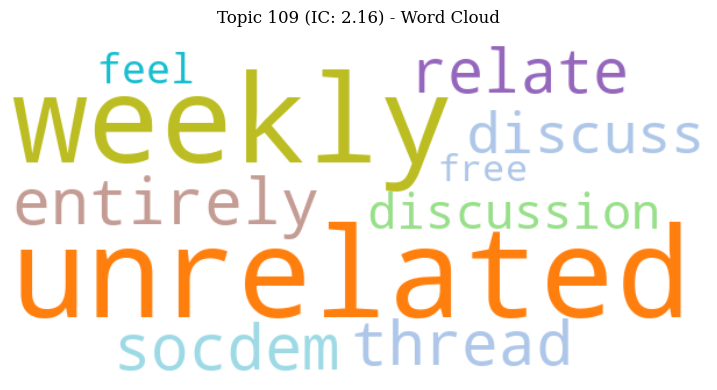

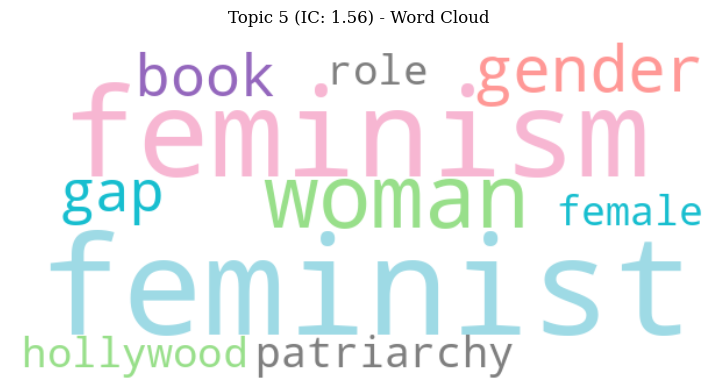

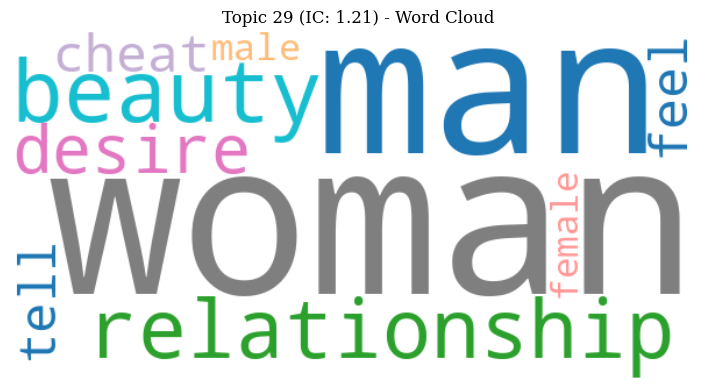

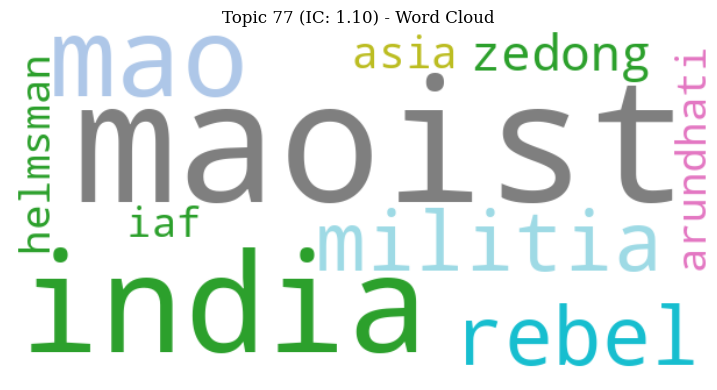

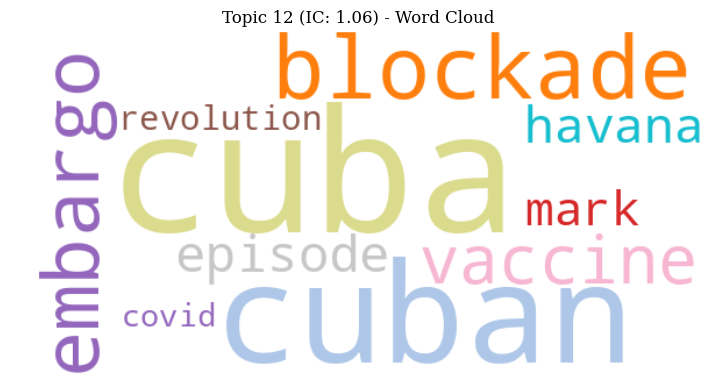

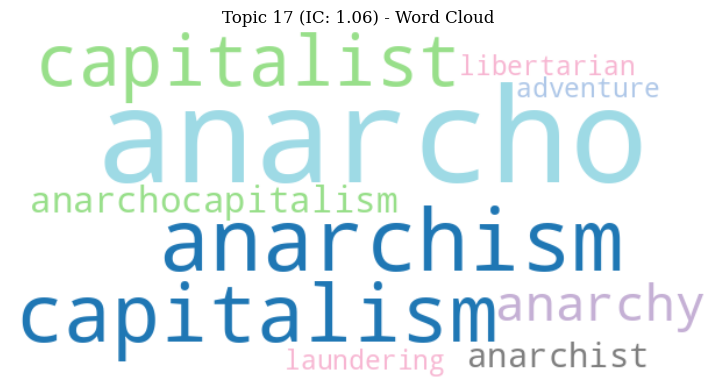

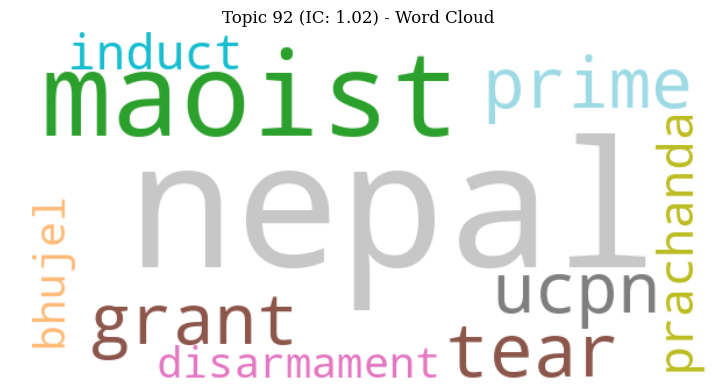

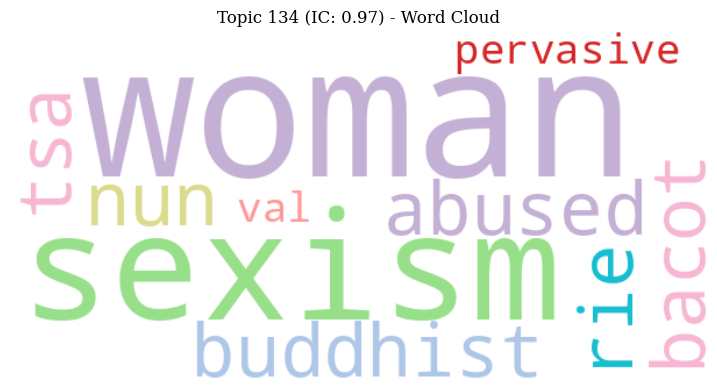

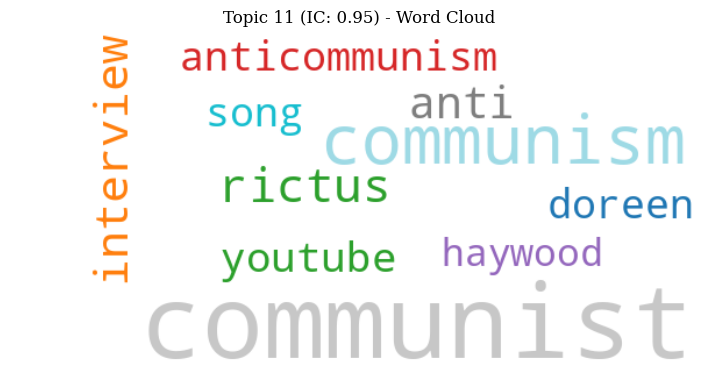

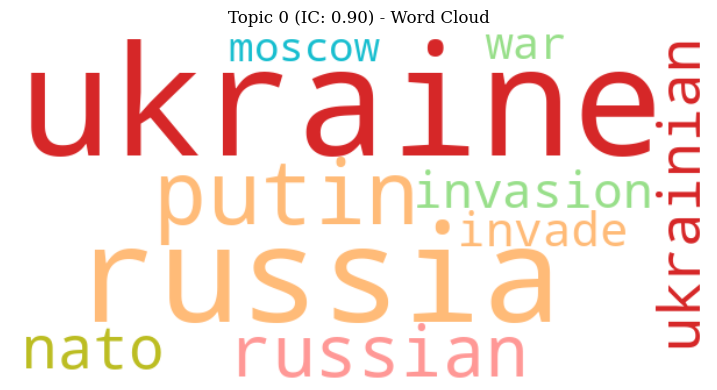

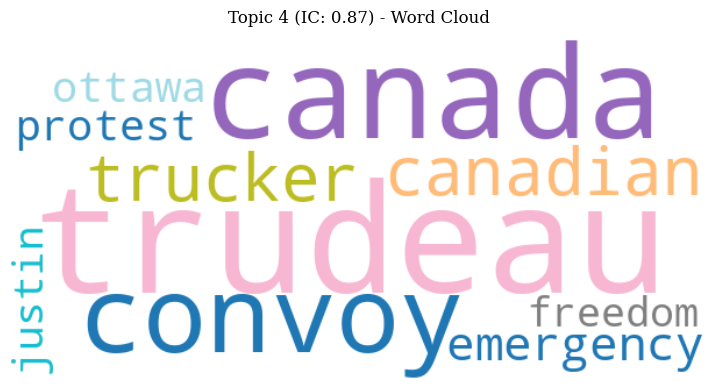

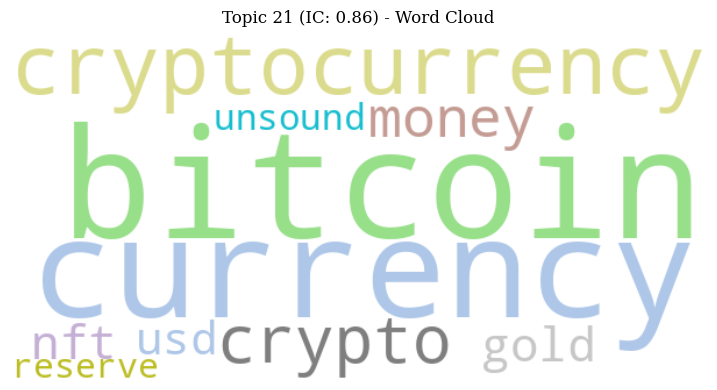

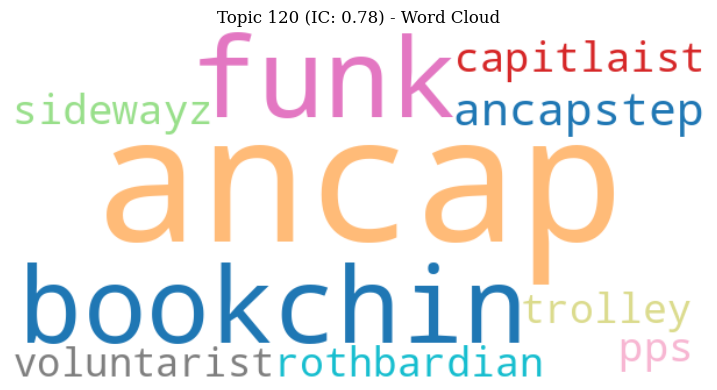

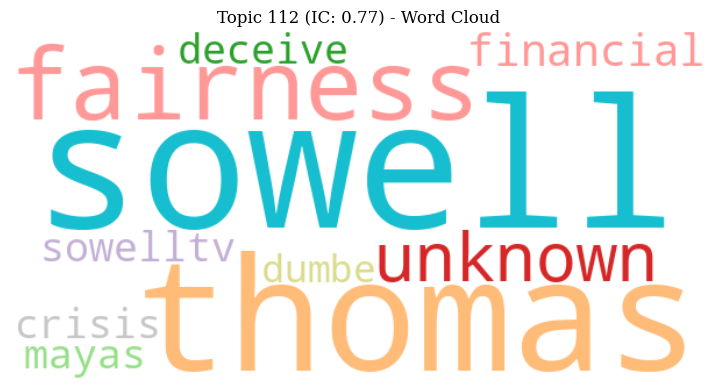

In [82]:
topics_wordcloud(filtered_topics, latex_table=True)

From this wordclouds, we can give a more meaningful name to the top most informative topics.

In [37]:
topic_names = {
    108 : "Reddit jargon",
    6   : "feminism",
    19  : "anarcho capitalism",
    67  : "maoism india",
    97  : "maoism nepal",
    37  : "man and woman",
    12  : "communism",
    1   : "Canada mask and vaccine protest",
    17  : "Cuba",
    128 : "ancap culture and typos",

}

### 5.5 Plot the Distribution Amongst Subreddits

In [38]:
def plot_topics_distrib(topics_ids):
    fig, axes = plt.subplots(5, 2, figsize=(16,18), sharex=True)
    axes = axes.flatten()

    for i, tid in enumerate(topics_ids):
        topic_dist = topic_by_sub_norm.loc[tid]
        topic_label = topic_names.get(tid, f"Topic {tid}")

        bar_colors = [node_color_dict[sub] for sub in topic_dist.index]

        axes[i].bar(topic_dist.index, topic_dist.values, color=bar_colors)
        axes[i].set_title(f"{topic_label} (Info Content: {info_content[tid]:.2f})")
        axes[i].set_ylabel("Normalized Probability")
        axes[i].tick_params(axis='x', rotation=90, labelbottom=True)  # <-- Make x-labels visible

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()


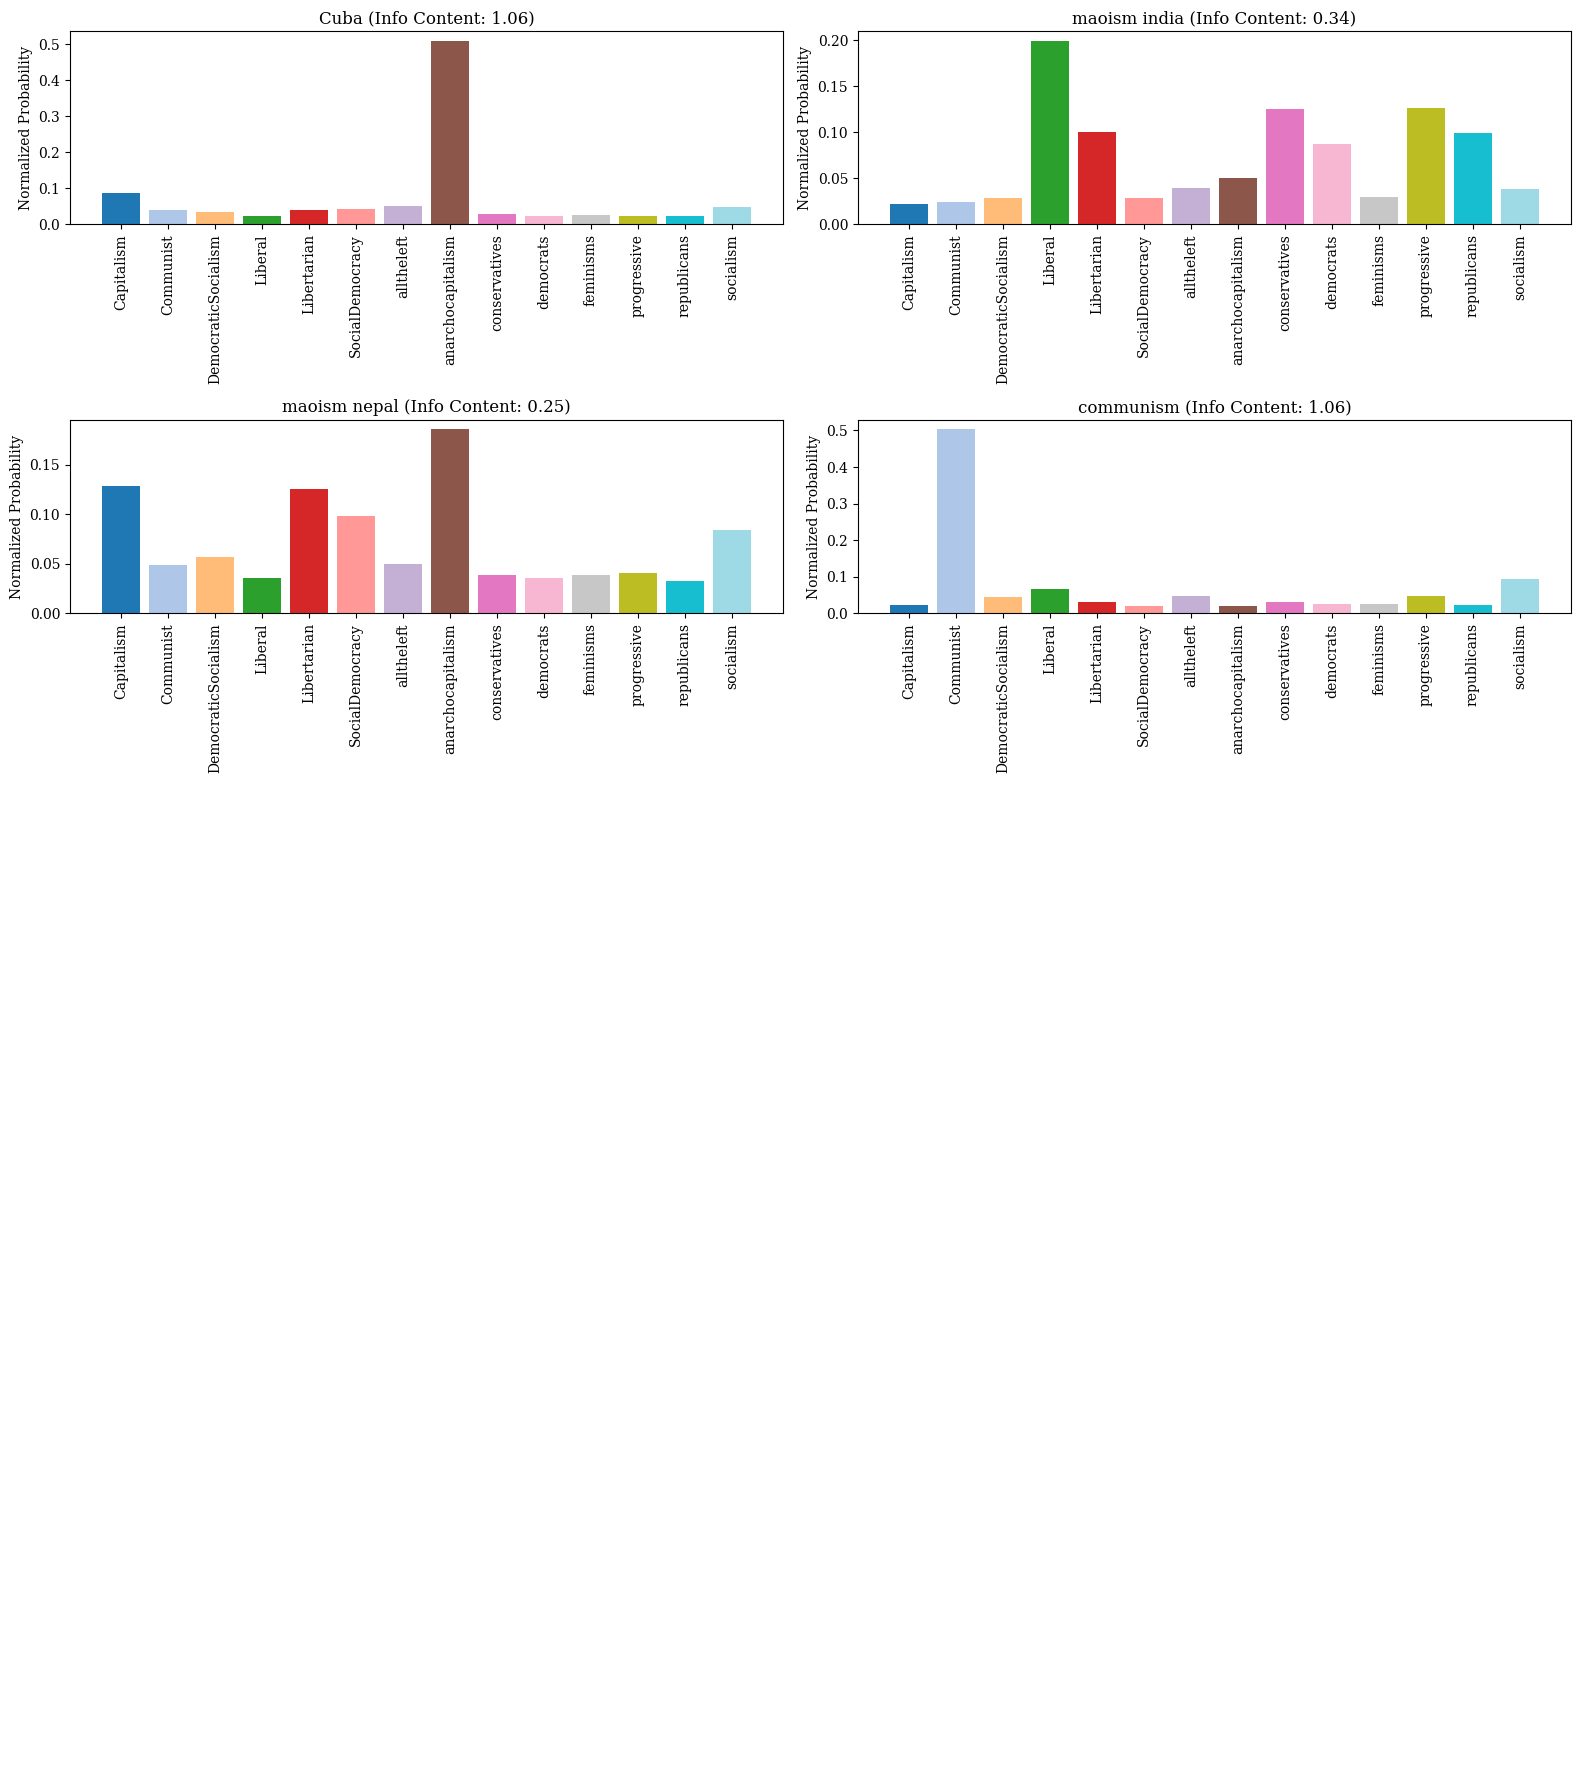

In [39]:
plot_topics_distrib([17, 67, 97, 12])

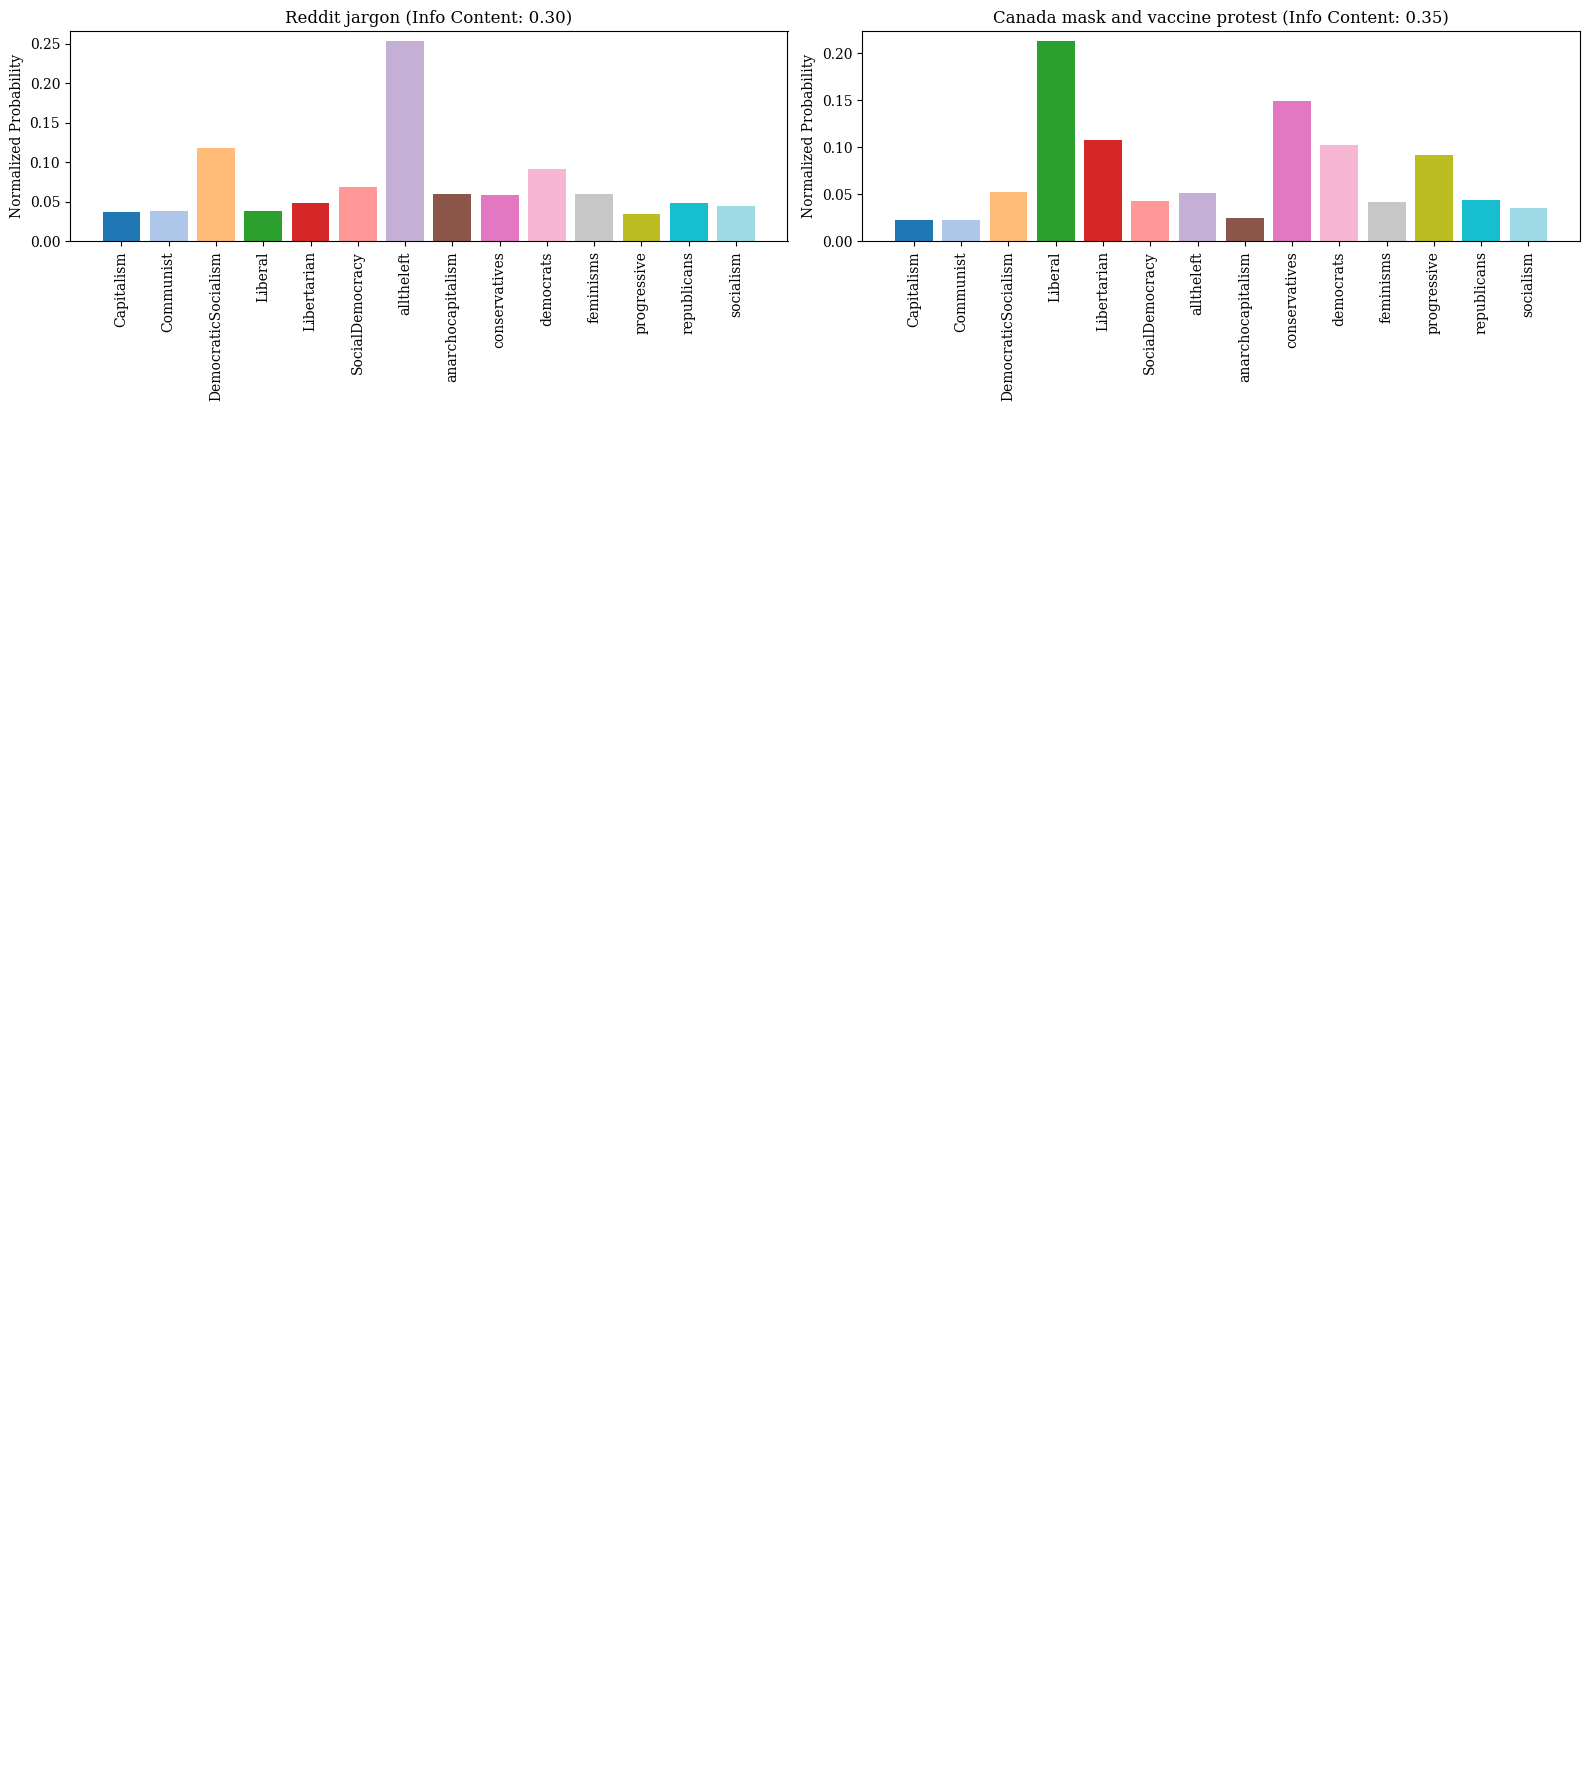

In [40]:
plot_topics_distrib([108, 1])

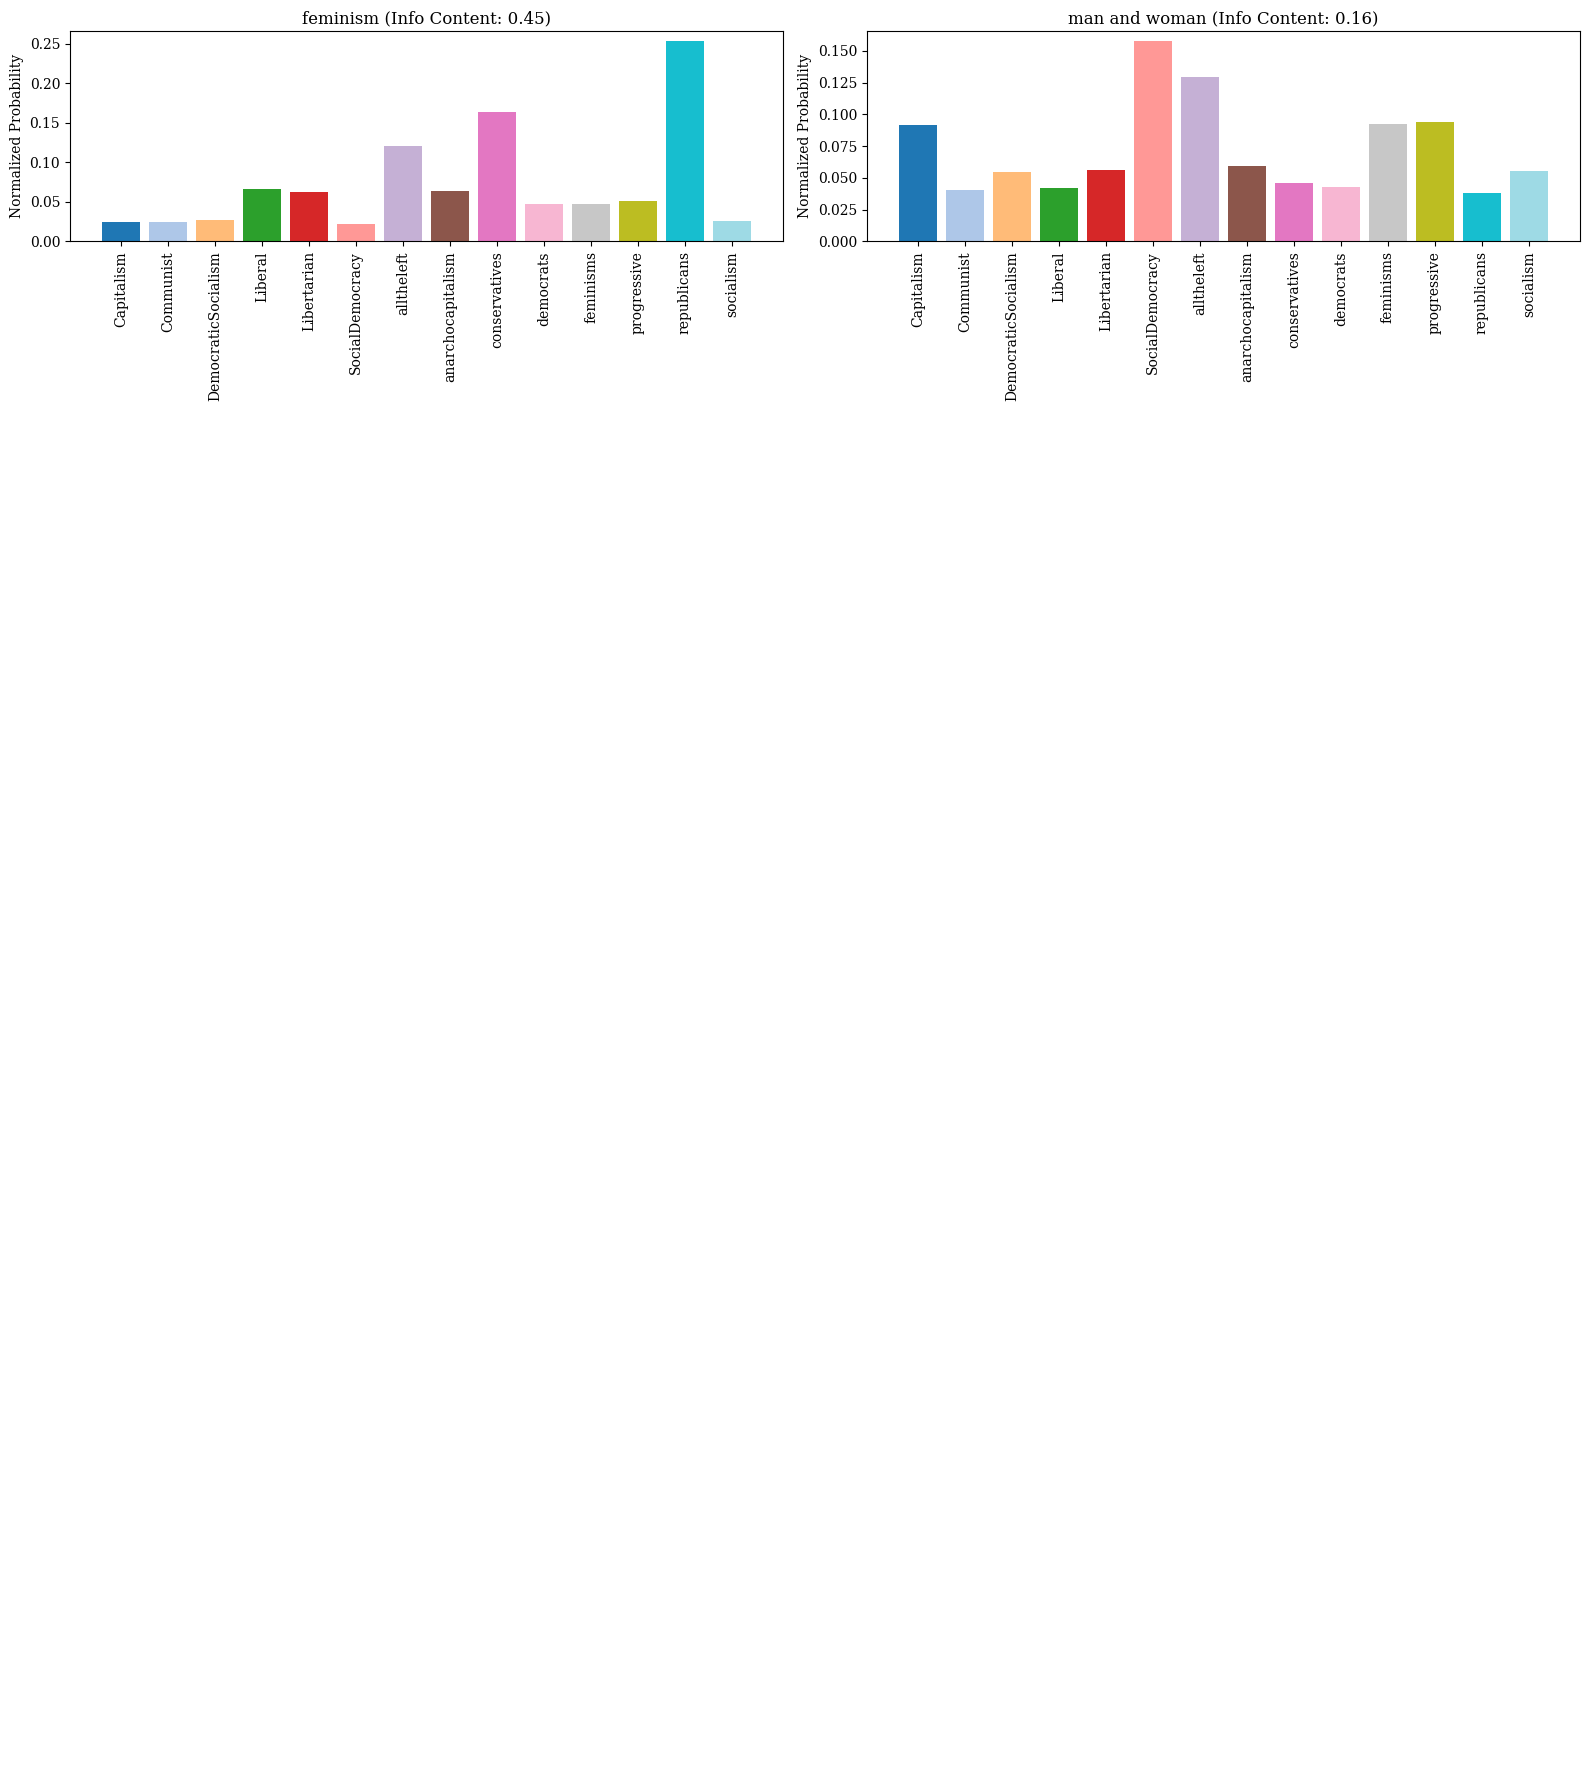

In [41]:
plot_topics_distrib([6, 37])

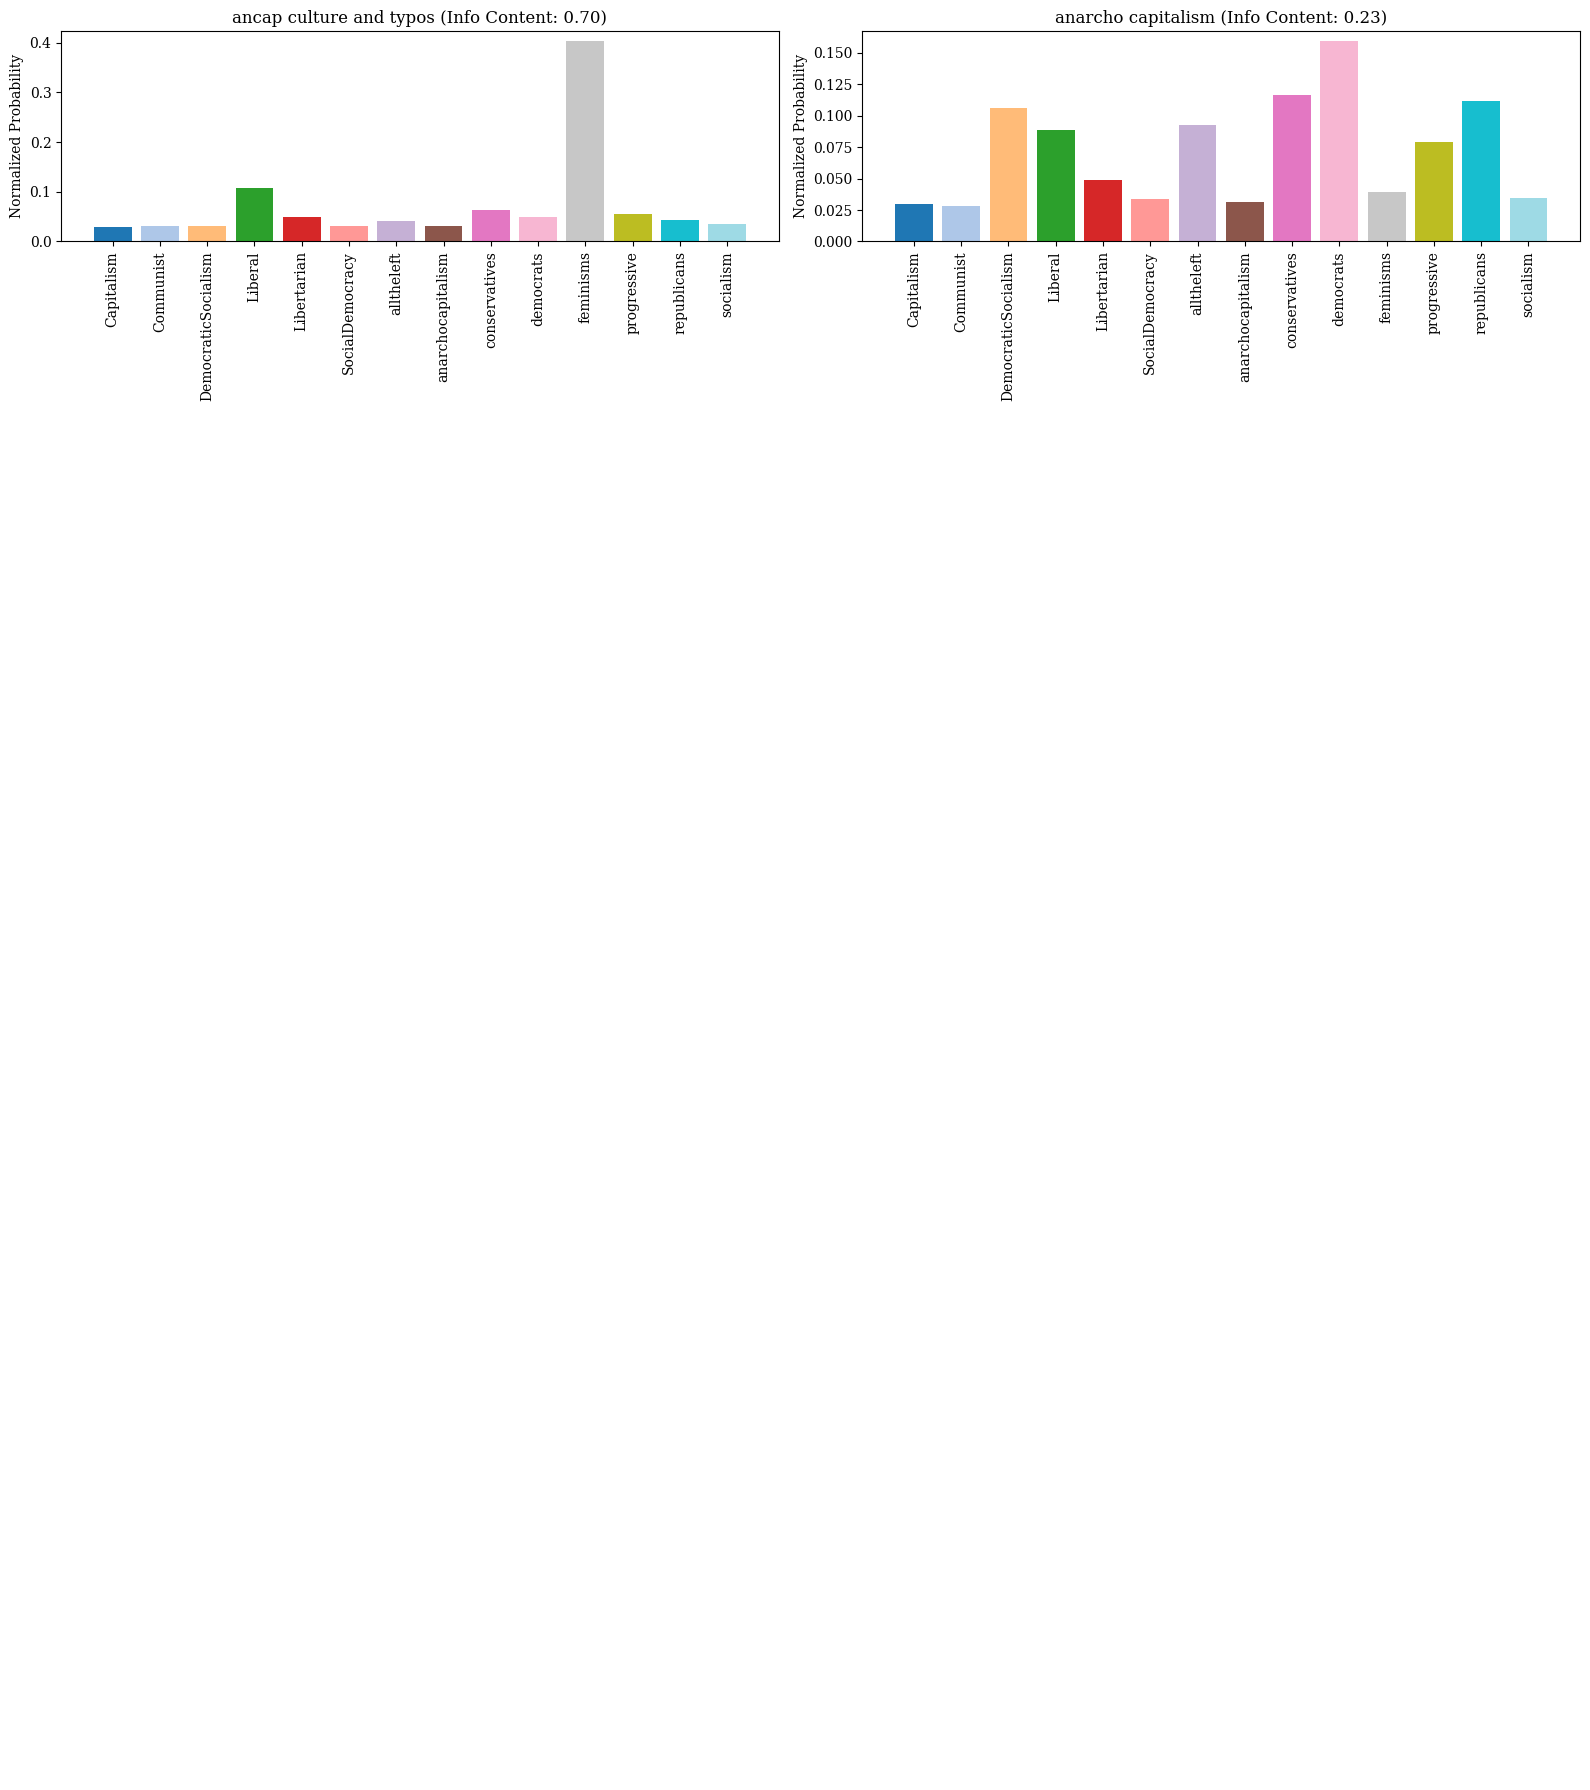

In [42]:
plot_topics_distrib([128, 19])

We can see that most of the topics around woman and sexuality are very distinctive of the *feminisms* subreddit. Canada mask and vaccine protest is a very *conservative* topic.

### 5.6 Least Informative Topics

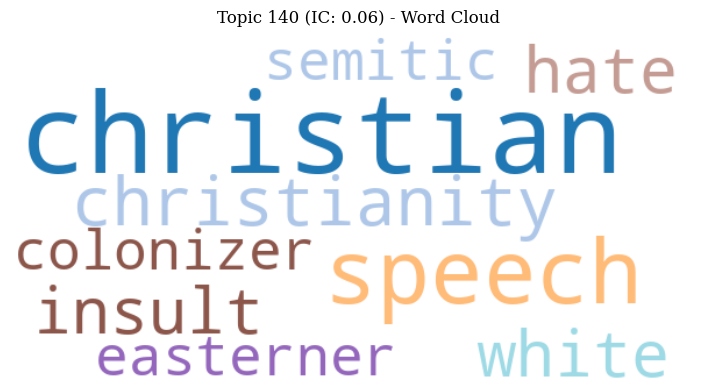

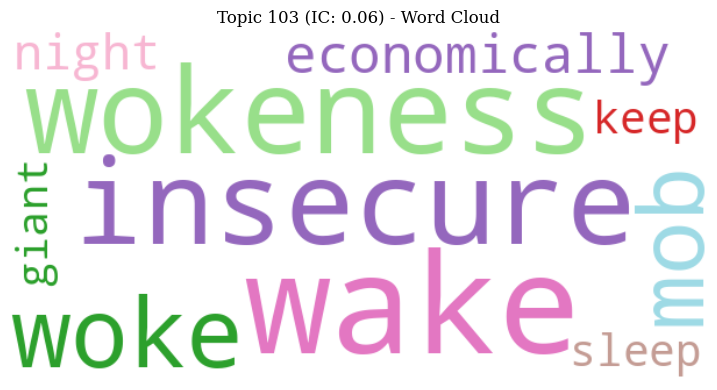

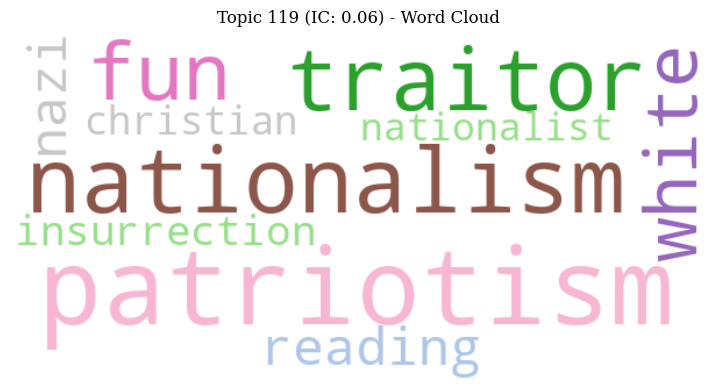

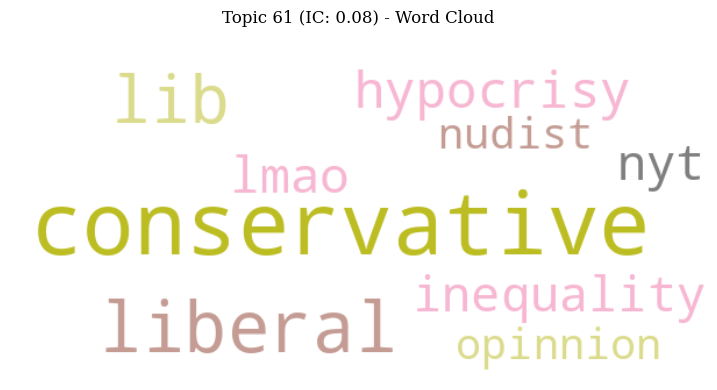

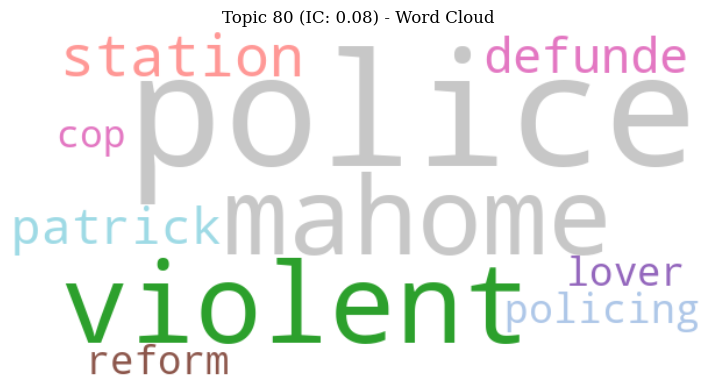

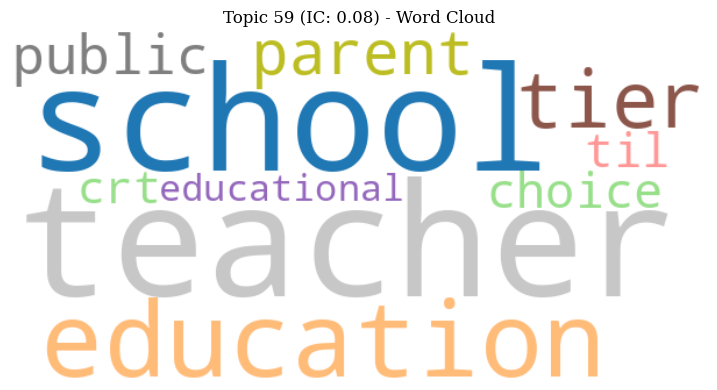

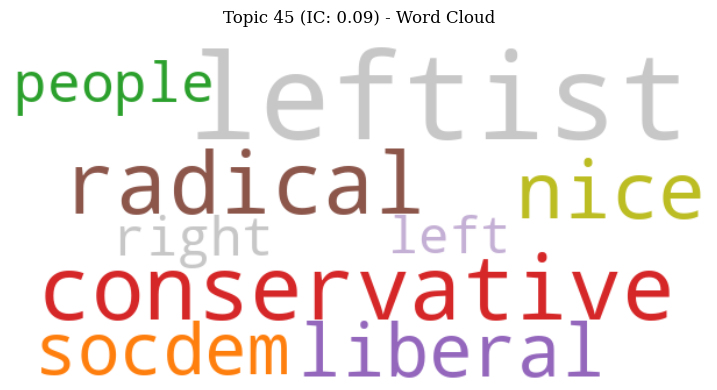

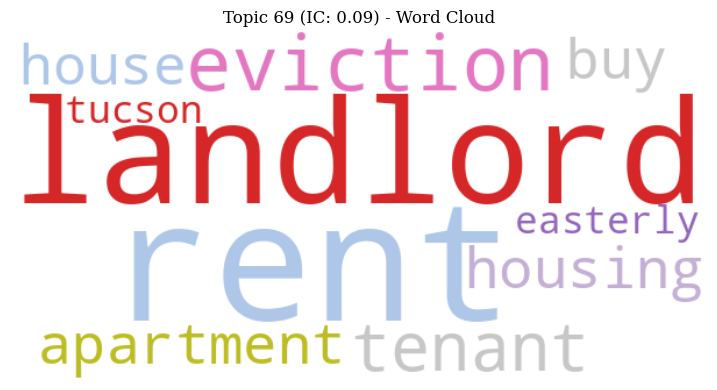

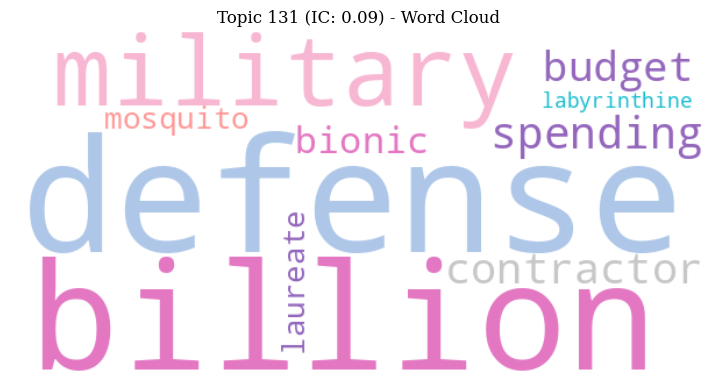

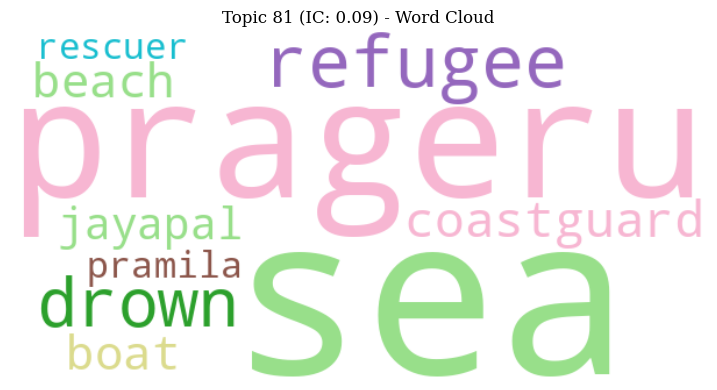

In [43]:
top_n = 10
min_info_topics = info_content.sort_values(ascending=True).index.tolist()[:top_n]
topics_wordcloud(min_info_topics)


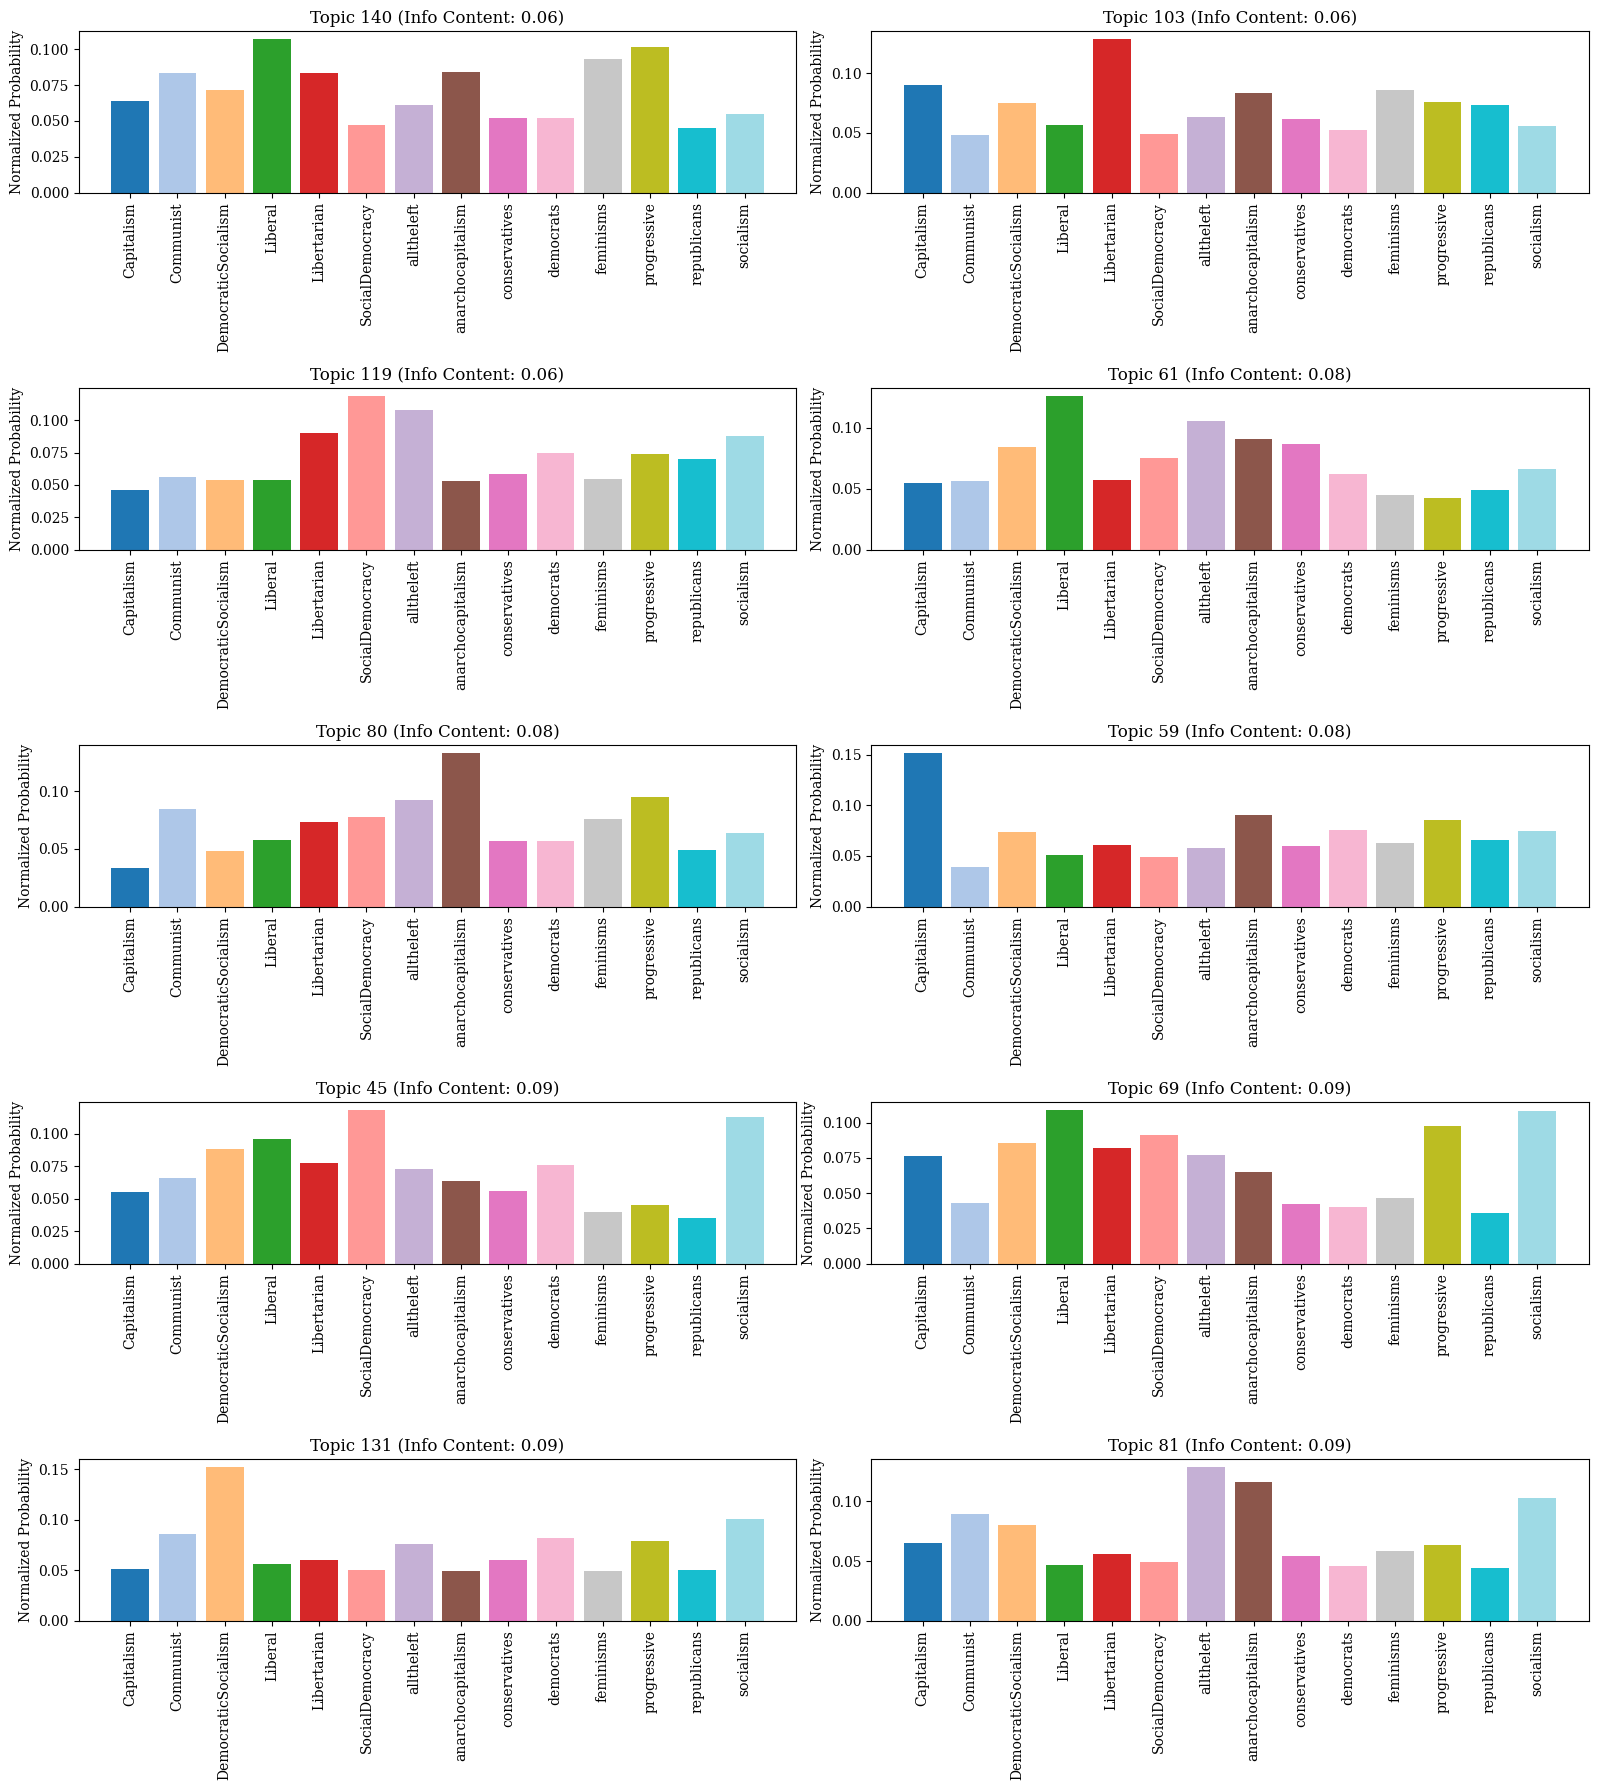

In [44]:
plot_topics_distrib(min_info_topics)

## 6. Predicting Subreddits based on Most Informative Subbredits
In this part, we try to perform the same predictive task by using only a cut of the most informatives Topics.

### 6.1 Rank Topics by Information Content

In [45]:
sorted_topic_ids = info_content.sort_values(ascending=False).index.tolist()

### 6.2 Evaluate Classifier Performance with 1 to all Most Informative Topics

In [47]:
max_k = len(sorted_topic_ids)
scores = []

for k in range(1, max_k + 1):
    top_k = sorted_topic_ids[:k]
    X_k = probs[:, top_k]  # select columns for top-k topics
    clf = LogisticRegression(max_iter=1000, multi_class='multinomial', solver='lbfgs')
    # Use macro F1 for multiclass
    f1 = cross_val_score(clf, X_k, y, cv=5, scoring="f1_macro").mean()
    scores.append(f1)

### 6.3 Plot Performance Evolution

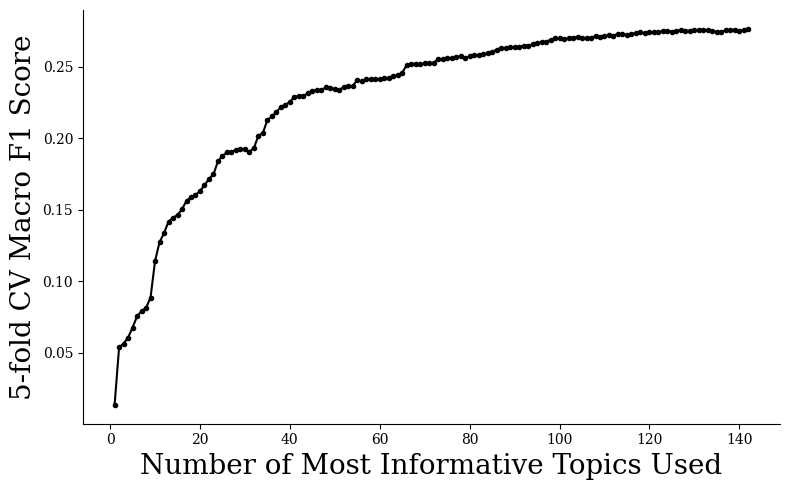

In [48]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, max_k + 1), scores, marker='.', color='black')
plt.xlabel('Number of Most Informative Topics Used', fontsize=20)
plt.ylabel('5-fold CV Macro F1 Score', fontsize=20)
# plt.title('Classifier Performance vs. Number of Most Informative Topics used (feature size)')
plt.grid(True, color='gray', linestyle='--', linewidth=0.5)
plt.grid(False)
ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.tight_layout()
plt.show()

In our case, while this approach is better for simplicity and interpretability, however it doesn't increase performances. Scaling the model's size in terms of number of topics when topics are sorted by information gain yields a logarithmic improvement of the models Macro F1 score. 
